## **The Data**

Spark SQL

The first of the two datasets that we will be working with is the **Farmers Markets Directory and Geographic Data**. This dataset contains information on the longitude and latitude, state, address, name, and zip code of farmers markets in the United States. The raw data is published by the Department of Agriculture. The version on the data that is found in Databricks (and is used in this tutorial) was updated by the Department of Agriculture on Dec 01, 2015.


The second dataset we will be working with is the **SOI Tax Stats - Individual Income Tax Statistics - ZIP Code Data (SOI)**. This study provides detailed tabulations of individual income tax return data at the state and ZIP code level and is provided by the IRS. This repository only has a sample of the data: 2013 and includes "AGI". The ZIP Code data shows selected income and tax items classified by State, ZIP Code, and size of adjusted gross income. Data is based on individual income tax returns filed with the IRS and is available for Tax Years 1998, 2001, 2004 through 2013.

# **Data Analysis**
Based on my analysis :

The current model performance is limited due to a constrained feature set and reliance on assumptions that do not accurately reflect real-world conditions. In particular, the use of shortened zip codes introduces information loss and fails to preserve geographic relationships, making it a weak predictor for spatial phenomena such as farmers market locations.

Additionally, the assumption that wealthier zip codes correlate with the presence of farmers markets reflects a non-causal relationship, which reduces the model’s ability to generalize effectively. Farmers markets are inherently location-dependent, and the absence of spatial features such as proximity or distance limits the model’s predictive capability.

To address these issues, further feature engineering can be explored by incorporating additional variables and introducing spatial awareness, such as neighboring regions or distance-based measures. Moreover, expanding hyperparameter tuning of the Random Forest model can help capture more complex patterns.

These refinements represent an iterative approach to model improvement, focusing on enhancing feature representation and model configuration rather than solely optimizing performance metrics.

**Alright, let’s start the experimentation.**

In [0]:
%python
# Read The data
taxes2013 = (spark.read
  .option("header", "true")
  .csv("dbfs:/databricks-datasets/data.gov/irs_zip_code_data/data-001/2013_soi_zipcode_agi.csv"))

markets = (spark.read
  .option("header", "true")
  .csv("dbfs:/databricks-datasets/data.gov/farmers_markets_geographic_data/data-001/market_data.csv"))

_**Data Check | Data Understanding**_



# Farmer's Market Directory and Geographic Data

In [0]:
%python
markets_clean = markets.toDF(*[c.replace(" ", "") for c in markets.columns])

print(markets_clean.columns)

['FMID', 'MarketName', 'Website', 'Facebook', 'Twitter', 'Youtube', 'OtherMedia', 'street', 'city', 'County', 'State', 'zip', 'Season1Date', 'Season1Time', 'Season2Date', 'Season2Time', 'Season3Date', 'Season3Time', 'Season4Date', 'Season4Time', 'x', 'y', 'Location', 'Credit', 'WIC', 'WICcash', 'SFMNP', 'SNAP', 'Organic', 'Bakedgoods', 'Cheese', 'Crafts', 'Flowers', 'Eggs', 'Seafood', 'Herbs', 'Vegetables', 'Honey', 'Jams', 'Maple', 'Meat', 'Nursery', 'Nuts', 'Plants', 'Poultry', 'Prepared', 'Soap', 'Trees', 'Wine', 'Coffee', 'Beans', 'Fruits', 'Grains', 'Juices', 'Mushrooms', 'PetFood', 'Tofu', 'WildHarvested', 'updateTime']


**_This makes the schema cleaner and easier to work with in Spark, especially when selecting, filtering, or joining columns._**

The dataset now shows all available fields, including:

- Market identifiers and info: FMID, MarketName, Website, and social media columns
- Address and location fields: street, city, County, State, zip, along with coordinates x and y
- Seasonal availability: multiple SeasonDate and SeasonTime columns
- Payment options: Credit, WIC, WICcash, SNAP, SFMNP
- Product indicators: binary-type columns such as Vegetables, Fruits, Meat, Eggs, Seafood, Honey, Plants, Coffee, etc.

Each column represents a specific attribute of a farmers’ market, structured as string fields after the transformation.

In [0]:
%python
from pyspark.sql.functions import trim, col

markets_clean = markets_clean.select([
    trim(col(c)).alias(c) if dict(markets_clean.dtypes)[c] == 'string' else col(c)
    for c in markets_clean.columns
])

# Schema and Data Type Validation

At this stage, I would formally address schema and data type validation based on the dataset structure I observed.

Currently, all columns in markets_clean are stored as string, which limits analytical accuracy and computational efficiency. For proper data processing, specific fields must be converted into appropriate data types aligned with their real-world meaning.

- **Geospatial Fields** (x, y)
These columns represent coordinates and should be converted to double. Keeping them as string prevents spatial calculations such as distance measurement, clustering, or mapping.
- **Binary Product & Program Fields**
Columns such as Vegetables, Fruits, Meat, SNAP, WIC, and similar attributes appear to represent yes/no indicators. These should be converted to boolean (true/false) or integer (1/0) to enable aggregation, filtering, and feature engineering.
- **Temporal Fields** (Season1Date, Season2Date, etc.)
These columns represent seasonal availability and should be converted to date format, provided the values are consistent and parsable. This allows time-based analysis such as seasonality patterns and availability trends.

This step ensures that each column reflects its true semantic type, enabling accurate querying, transformation, and downstream modeling.

In [0]:
%python
from pyspark.sql.functions import col, when

In [0]:
%python
# =========================
# 1. CAST GEOSPATIAL FIELDS
# =========================
markets_typed = markets_clean \
    .withColumn("x", col("x").cast("double")) \
    .withColumn("y", col("y").cast("double"))

In [0]:
%python
# =========================
# 2. CONVERT BINARY FIELDS
# =========================
binary_cols = [
    "Credit","WIC","WICcash","SFMNP","SNAP","Organic",
    "Bakedgoods","Cheese","Crafts","Flowers","Eggs","Seafood",
    "Herbs","Vegetables","Honey","Jams","Maple","Meat","Nursery",
    "Nuts","Plants","Poultry","Prepared","Soap","Trees","Wine",
    "Coffee","Beans","Fruits","Grains","Juices","Mushrooms",
    "PetFood","Tofu","WildHarvested"
]

for c in binary_cols:
    markets_typed = markets_typed.withColumn(
        c,
        when(col(c).isin("Y", "Yes", "1", "TRUE", "True"), 1).otherwise(0)
    )

In [0]:
%python
# =========================
# 3. CAST DATE FIELDS
# =========================
date_cols = [
    "Season1Date","Season2Date","Season3Date","Season4Date"
]

for c in date_cols:
    markets_typed = markets_typed.withColumn(
        c,
        col(c).cast("date")
    )

In [0]:
%python
# =========================
# 4. VERIFY SCHEMA
# =========================
markets_typed.printSchema()

root
 |-- FMID: string (nullable = true)
 |-- MarketName: string (nullable = true)
 |-- Website: string (nullable = true)
 |-- Facebook: string (nullable = true)
 |-- Twitter: string (nullable = true)
 |-- Youtube: string (nullable = true)
 |-- OtherMedia: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- Season1Date: date (nullable = true)
 |-- Season1Time: string (nullable = true)
 |-- Season2Date: date (nullable = true)
 |-- Season2Time: string (nullable = true)
 |-- Season3Date: date (nullable = true)
 |-- Season3Time: string (nullable = true)
 |-- Season4Date: date (nullable = true)
 |-- Season4Time: string (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- Credit: integer (nullable = false)
 |-- WIC: integer (nullable = false)
 |-- WICcash: i

**Note :**

I performed schema and data type validation by converting key columns from string into their appropriate formats.

- I cast the geospatial fields (x, y) to double to enable accurate spatial analysis and coordinate-based operations.
- I standardized the binary indicator columns (e.g., Vegetables, Fruits, SNAP, WIC) into numeric format (1/0) to support consistent aggregation and filtering.
- I converted the seasonal date fields (Season1Date to Season4Date) into date type to allow time-based analysis.

These transformations ensure the dataset reflects its true structure and is properly prepared for further processing.

# Data Quality Checks

Performed data quality checks to ensure the dataset is reliable before moving forward.

- Null / missing values need to be identified because incomplete fields (e.g., FMID, location, coordinates) can break analysis, lead to incorrect results, or affect transformations.
- Inconsistent formats in binary columns (like Vegetables, Fruits, SNAP, WIC) must be standardized since values such as “Yes”, “Y”, and “1” represent the same thing but can distort aggregations if left uncleaned.
- Duplicate records (based on FMID) must be validated to ensure each market is uniquely represented, avoiding inflated counts and biased insights.

These checks are critical to maintain data consistency and accuracy before any analysis or modeling.

In [0]:
%python
from pyspark.sql.functions import col, split, to_date

# Extract START DATE from range
markets_typed = markets_typed \
    .withColumn("Season1Start", to_date(split(col("Season1Date"), " to ")[0], "MM/dd/yyyy")) \
    .withColumn("Season2Start", to_date(split(col("Season2Date"), " to ")[0], "MM/dd/yyyy")) \
    .withColumn("Season3Start", to_date(split(col("Season3Date"), " to ")[0], "MM/dd/yyyy")) \
    .withColumn("Season4Start", to_date(split(col("Season4Date"), " to ")[0], "MM/dd/yyyy"))

This is exactly why data quality matters.

**The issue is:**

- SeasonDate columns contain ranges like "05/01/2014 to 09/25/2014"
- A date type expects a single date, not a range → casting fails

In [0]:
%python
# =========================
# 2. CHECK INCONSISTENT FORMATS (BEFORE STANDARDIZATION)
# Example: check distinct values in binary columns
# =========================
binary_cols = [
    "Vegetables","Fruits","Meat","SNAP","WIC"
]

for c in binary_cols:
    print(f"Distinct values in {c}:")
    markets_clean.select(c).distinct().show()


Distinct values in Vegetables:
+----------+
|Vegetables|
+----------+
|         N|
|         Y|
+----------+

Distinct values in Fruits:
+------+
|Fruits|
+------+
|     N|
|     Y|
+------+

Distinct values in Meat:
+----+
|Meat|
+----+
|   N|
|   Y|
+----+

Distinct values in SNAP:
+----+
|SNAP|
+----+
|   N|
|   Y|
+----+

Distinct values in WIC:
+---+
|WIC|
+---+
|  N|
|  Y|
+---+



In [0]:
%python
# =========================
# 3. CHECK DUPLICATES (FMID)
# =========================
duplicates = markets_typed.groupBy("FMID").count().filter(col("count") > 1)

duplicates.show()

+----+-----+
|FMID|count|
+----+-----+
+----+-----+



In [0]:
%python
# Count how many duplicates exist
duplicate_count = duplicates.count()
print(f"Total duplicate FMIDs: {duplicate_count}")

Total duplicate FMIDs: 0


Data quality checks were performed to ensure the dataset is clean, consistent, and reliable before moving into analysis.

- **Null / Missing Values**
Checked across all columns to identify incomplete records. This is important because missing values in key fields like FMID, location (city, State, zip), or coordinates (x, y) can affect spatial analysis, aggregations, and overall data integrity.
- **Inconsistent Formats**
Observed in binary columns such as Vegetables, Fruits, SNAP, and WIC, where values may appear as “Yes”, “Y”, or “1”. Standardizing these ensures that all indicators follow a consistent structure, preventing errors in counting and feature engineering.
- **Duplicate Records (FMID)**
Validated using FMID as the unique identifier. This ensures that each market is represented once, avoiding duplication that could distort distributions, totals, and insights.
- **Date Field Issues**
Identified that seasonal date columns contain date ranges (e.g., "05/01/2014 to 09/25/2014"), not single dates. This required parsing and splitting before conversion, ensuring temporal fields are usable for analysis.

These checks confirm that the dataset is structurally sound and ready for accurate downstream analysis.

# Column Relevance Checks



Column relevance and selection to focus only on features that contribute to analysis and reduce noise from the dataset.

- Core analytical features were identified based on the objective of understanding market distribution, product availability, and program access. 

**These include:**
- Location fields: city, State, zip, x, y → essential for spatial and regional analysis
- Product indicators: Vegetables, Fruits, Meat, Eggs, Seafood, etc. → used to analyze product diversity and availability
- Program/payment fields: SNAP, WIC, SFMNP, Credit → important for evaluating accessibility and support programs
- Identifiers: FMID, MarketName → required for tracking and grouping markets

Non-essential / noisy fields were identified as those that do not directly contribute to the analysis objective, 

**such as:**
- Social media columns: Facebook, Twitter, Youtube, OtherMedia
- Website links: Website
- Some descriptive or rarely used fields depending on scope

Separating these ensures the dataset remains focused, efficient, and easier to work with, especially for modeling and visualization.

In [0]:
%python
# Define core features
core_columns = [
    # Identifiers
    "FMID", "MarketName",
    
    # Location
    "city", "State", "zip", "x", "y",
    
    # Programs / Payments
    "SNAP", "WIC", "SFMNP", "Credit",
    
    # Products (FIXED)
    "Vegetables", "Fruits", "Meat", "Eggs", "Seafood",
    "Cheese", "Bakedgoods", "Honey", "Plants", "Coffee"
]

markets_selected = markets_typed.select(core_columns)

# VERIFY
markets_selected.printSchema()
markets_selected.show(10)

root
 |-- FMID: string (nullable = true)
 |-- MarketName: string (nullable = true)
 |-- city: string (nullable = true)
 |-- State: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- SNAP: integer (nullable = false)
 |-- WIC: integer (nullable = false)
 |-- SFMNP: integer (nullable = false)
 |-- Credit: integer (nullable = false)
 |-- Vegetables: integer (nullable = false)
 |-- Fruits: integer (nullable = false)
 |-- Meat: integer (nullable = false)
 |-- Eggs: integer (nullable = false)
 |-- Seafood: integer (nullable = false)
 |-- Cheese: integer (nullable = false)
 |-- Bakedgoods: integer (nullable = false)
 |-- Honey: integer (nullable = false)
 |-- Plants: integer (nullable = false)
 |-- Coffee: integer (nullable = false)

+-------+--------------------+-----------+--------------------+-----+-----------+----------+----+---+-----+------+----------+------+----+----+-------+------+----------+-----+------+---

In [0]:
%python
# SELECT ONLY RELEVANT COLUMNS
markets_selected = markets_typed.select(core_columns)

In [0]:
%python
# VERIFY
markets_selected.printSchema()
markets_selected.show(5)

root
 |-- FMID: string (nullable = true)
 |-- MarketName: string (nullable = true)
 |-- city: string (nullable = true)
 |-- State: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- SNAP: integer (nullable = false)
 |-- WIC: integer (nullable = false)
 |-- SFMNP: integer (nullable = false)
 |-- Credit: integer (nullable = false)
 |-- Vegetables: integer (nullable = false)
 |-- Fruits: integer (nullable = false)
 |-- Meat: integer (nullable = false)
 |-- Eggs: integer (nullable = false)
 |-- Seafood: integer (nullable = false)
 |-- Cheese: integer (nullable = false)
 |-- Bakedgoods: integer (nullable = false)
 |-- Honey: integer (nullable = false)
 |-- Plants: integer (nullable = false)
 |-- Coffee: integer (nullable = false)

+-------+--------------------+---------+--------------+-----+-----------+---------+----+---+-----+------+----------+------+----+----+-------+------+----------+-----+------+------+
|   

Completed column relevance and selection by filtering the dataset to only include features that directly support the analysis objective.

Retained core analytical features such as:

- Identifiers (FMID, MarketName) for tracking and grouping
- Location fields (city, State, zip, x, y) to enable spatial and regional analysis
- Program indicators (SNAP, WIC, SFMNP, Credit) to assess accessibility and support systems
- Product indicators (Vegetables, Fruits, Meat, Eggs, Seafood, Cheese, etc.) to evaluate availability and diversity
- Removed non-essential fields such as social media links and website-related columns, as they do not contribute to the current analytical scope.

This step reduced noise, improved data clarity, and ensured the dataset is focused, efficient, and ready for aggregation, visualization, and modeling.

# Initial Feature Understanding

Initial feature understanding to define how each variable will be used in the analysis.

Feature categorization is needed to properly structure the dataset:
- Categorical features (city, State, zip, MarketName) are needed for grouping and regional comparisons
- Numerical features (binary columns like Vegetables, Fruits, Meat, SNAP, WIC) are needed for aggregation, counting, and scoring
- Geospatial features (x, y) are needed for mapping, clustering, and spatial analysis

Identifying potential targets is needed to guide the direction of the analysis:
- Market density is needed to understand how markets are distributed across regions
- Product diversity is needed to measure availability and variety of goods per market
- Program accessibility is needed to evaluate the presence of support systems like SNAP, WIC, and SFMNP

This step ensures the dataset is logically structured and aligned with clear analytical goals before proceeding.

In [0]:
%python
# =========================
# 1. FEATURE CATEGORIZATION
# =========================

categorical_features = ["city", "State", "zip", "MarketName"]

numerical_features = [
    "Vegetables", "Fruits", "Meat", "Eggs", "Seafood",
    "Cheese", "Bakedgoods", "Honey", "Plants", "Coffee",
    "SNAP", "WIC", "SFMNP", "Credit"
]

geospatial_features = ["x", "y"]

In [0]:
%python
# =========================
# 2. MARKET DENSITY (by State)
# =========================
market_density = markets_selected.groupBy("State").count() \
    .withColumnRenamed("count", "market_count")

market_density.show()


+--------------+------------+
|         State|market_count|
+--------------+------------+
|      Maryland|         157|
|        Nevada|          39|
|        Hawaii|          97|
|      Michigan|         339|
|       Florida|         252|
|North Carolina|         252|
|       Arizona|          92|
|          Ohio|         321|
|  Rhode Island|          58|
|South Carolina|         128|
|      New York|         666|
|      Nebraska|          97|
|     Wisconsin|         304|
| West Virginia|          88|
|   Mississippi|          82|
|       Vermont|          97|
|        Alaska|          37|
|  Pennsylvania|         303|
|    Washington|         169|
|         Maine|          93|
+--------------+------------+
only showing top 20 rows


In [0]:
%python
# =========================
# 3. PRODUCT DIVERSITY (per market)
# =========================

from functools import reduce
from pyspark.sql.functions import col

product_cols = [
    "Vegetables", "Fruits", "Meat", "Eggs", "Seafood",
    "Cheese", "Bakedgoods", "Honey", "Plants", "Coffee"
]

markets_features = markets_selected.withColumn(
    "product_diversity",
    reduce(lambda a, b: a + b, [col(c) for c in product_cols])
)

markets_features.select("FMID", "MarketName", "product_diversity").show(5)

+-------+--------------------+-----------------+
|   FMID|          MarketName|product_diversity|
+-------+--------------------+-----------------+
|1000618|     100-Mile Market|                9|
|1009364|106 S. Main Stree...|                0|
|1010691|10th Steet Commun...|                7|
|1002454|112st Madison Avenue|                3|
|1011100|12 South Farmers ...|                8|
+-------+--------------------+-----------------+
only showing top 5 rows


In [0]:
%python
# =========================
# 4. PROGRAM ACCESSIBILITY (by State)
# =========================
from pyspark.sql.functions import sum as _sum

program_access = markets_selected.groupBy("State").agg(
    _sum("SNAP").alias("total_snap"),
    _sum("WIC").alias("total_wic"),
    _sum("SFMNP").alias("total_sfmnp")
)

program_access.show()

+--------------+----------+---------+-----------+
|         State|total_snap|total_wic|total_sfmnp|
+--------------+----------+---------+-----------+
|      Maryland|        36|      106|         90|
|        Nevada|        12|        1|         22|
|        Hawaii|        37|        0|         28|
|      Michigan|       150|      148|        150|
|       Florida|        44|       19|         15|
|North Carolina|        53|       34|         37|
|       Arizona|        27|       34|         36|
|          Ohio|        81|       74|         66|
|  Rhode Island|        20|       26|         32|
|South Carolina|        23|       22|         29|
|      New York|       258|      366|        348|
|      Nebraska|        11|       18|         41|
|     Wisconsin|        68|      134|        106|
| West Virginia|        27|       31|         50|
|   Mississippi|        26|       13|         23|
|       Vermont|        50|       33|         29|
|        Alaska|         9|       15|         12|


- **total_snap** :  total number of markets in each State that support the SNAP (Supplemental Nutrition Assistance Program).
(Basically counts how many markets accept SNAP benefits.)
- **total_wic** : total number of markets in each State that support WIC (Women, Infants, and Children program).
(Shows accessibility of WIC-supported markets.)
- **total_sfmnp** : total number of markets in each State that support SFMNP (Senior Farmers’ Market Nutrition Program).
(Indicates how many markets serve senior nutrition programs.)

These columns were converted to 1 (yes) / 0 (no), the sum gives the count of markets offering each program per state.

**Note:**

Performed initial feature understanding to structure the dataset and clearly define how each feature contributes to the analysis. Features were categorized based on their role: categorical features such as city, State, zip, and MarketName are used for grouping and regional segmentation; numerical features, including binary indicators like Vegetables, Fruits, Meat, SNAP, and WIC, are used for aggregation and quantitative analysis; and geospatial features (x, y) are used for mapping and spatial distribution. Based on this structure, key analytical directions were established. Market density was derived by counting the number of markets per state to understand distribution patterns, product diversity was calculated by summing product indicators to measure the variety of goods available per market, and program accessibility was analyzed by aggregating SNAP, WIC, and SFMNP to evaluate how widely support programs are available across regions.

# Prepare for Transformation

Prepared for data transformation by defining how features will be structured for analysis and modeling.

- An encoding strategy for product columns is needed because product indicators such as Vegetables, Fruits, Meat, and others are currently represented as separate binary fields. These can be used directly for aggregation, or further transformed (e.g., combined into scores like product diversity) to simplify analysis and improve interpretability.

The aggregation level needs to be clearly defined depending on the objective:
-  City level → to analyze local patterns and market distribution within specific areas
- State level → to compare broader regional trends and accessibility
- ZIP level → to achieve more granular, location-specific insights

This step ensures that transformations are aligned with the analytical goals and that the dataset is structured appropriately for meaningful insights.

In [0]:
%python
from pyspark.sql.functions import col, sum as _sum
from functools import reduce

In [0]:
%python
# =========================
# 1. PRODUCT ENCODING (already 1/0, now structured)
# =========================

product_cols = [
    "Vegetables", "Fruits", "Meat", "Eggs", "Seafood",
    "Cheese", "Bakedgoods", "Honey", "Plants", "Coffee"
]

# Create product diversity score (encoded feature)
markets_transformed = markets_selected.withColumn(
    "product_diversity",
    reduce(lambda a, b: a + b, [col(c) for c in product_cols])
)


In [0]:
%python
# =========================
# 2. AGGREGATION LEVELS
# =========================

# --- CITY LEVEL ---
city_agg = markets_transformed.groupBy("city", "State").agg(
    _sum("product_diversity").alias("total_product_diversity"),
    _sum("SNAP").alias("total_snap"),
    _sum("WIC").alias("total_wic")
)

# --- STATE LEVEL ---
state_agg = markets_transformed.groupBy("State").agg(
    _sum("product_diversity").alias("total_product_diversity"),
    _sum("SNAP").alias("total_snap"),
    _sum("WIC").alias("total_wic")
)

# --- ZIP LEVEL ---
zip_agg = markets_transformed.groupBy("zip").agg(
    _sum("product_diversity").alias("total_product_diversity"),
    _sum("SNAP").alias("total_snap"),
    _sum("WIC").alias("total_wic")
)

In [0]:
%python
# =========================
# 3. VERIFY OUTPUTS
# =========================
city_agg.show(5)
state_agg.show(5)
zip_agg.show(5)

+-----------+--------------+-----------------------+----------+---------+
|       city|         State|total_product_diversity|total_snap|total_wic|
+-----------+--------------+-----------------------+----------+---------+
|   Six Mile|South Carolina|                      0|         0|        0|
|Scottsbluff|      Nebraska|                      9|         0|        0|
|   Acushnet| Massachusetts|                      7|         0|        1|
|        Ada|      Oklahoma|                      2|         0|        0|
|        Ada|      Michigan|                      9|         1|        0|
+-----------+--------------+-----------------------+----------+---------+
only showing top 5 rows
+--------+-----------------------+----------+---------+
|   State|total_product_diversity|total_snap|total_wic|
+--------+-----------------------+----------+---------+
|Maryland|                    783|        36|      106|
|  Nevada|                    170|        12|        1|
|  Hawaii|                    

Completed data transformation preparation and execution by structuring product features and defining aggregation levels aligned with the analysis objectives.

Product encoding was utilized by leveraging existing binary indicators (1/0) for product categories such as Vegetables, Fruits, Meat, and others. These were combined into a derived feature, product_diversity, representing the total number of product types available per market. This provides a measurable indicator of market richness and variety.
Aggregation levels were applied to analyze the data at multiple geographic resolutions:
City-level aggregation enables localized insights into product availability and program accessibility within specific areas
State-level aggregation provides a broader comparison of market distribution, diversity, and support program reach across regions
ZIP-level aggregation allows for more granular analysis, supporting fine-level geographic exploration
Aggregated metrics such as total product diversity, total SNAP, and total WIC participation were computed to quantify availability and accessibility across each level.

This transformation establishes a structured dataset that supports multi-level analysis, enabling clear comparisons across geographic regions and facilitating deeper insights into market distribution, product diversity, and program accessibility.

# Data is now clean - structured - transformed
# Now it’s time to extract insights and tell the story of the data

Part 2

# Distribution Analysis 

In [0]:
%python
# =========================
# 1. DISTRIBUTION ANALYSIS
# =========================
from pyspark.sql.functions import col


In [0]:
%python
# -------------------------
# A. MARKET DISTRIBUTION BY STATE
# -------------------------
state_distribution = markets_selected.groupBy("State").count() \
    .withColumnRenamed("count", "market_count") \
    .orderBy(col("market_count").desc())

state_distribution.show(10)

+-------------+------------+
|        State|market_count|
+-------------+------------+
|   California|         764|
|     New York|         666|
|     Michigan|         339|
|     Illinois|         324|
|         Ohio|         321|
|Massachusetts|         308|
|    Wisconsin|         304|
| Pennsylvania|         303|
|     Missouri|         261|
|      Florida|         252|
+-------------+------------+
only showing top 10 rows


In [0]:
%python
# -------------------------
# B. MARKET DISTRIBUTION BY CITY
# -------------------------
city_distribution = markets_selected.groupBy("city", "State").count() \
    .withColumnRenamed("count", "market_count") \
    .orderBy(col("market_count").desc())

city_distribution.show(10)


+-------------+--------------------+------------+
|         city|               State|market_count|
+-------------+--------------------+------------+
|      Chicago|            Illinois|          59|
| Philadelphia|        Pennsylvania|          49|
|     New York|            New York|          47|
|     Brooklyn|            New York|          42|
|  Los Angeles|          California|          31|
|   Washington|District of Columbia|          30|
|  Minneapolis|           Minnesota|          30|
|        Bronx|            New York|          29|
|San Francisco|          California|          27|
|     Portland|              Oregon|          24|
+-------------+--------------------+------------+
only showing top 10 rows


In [0]:
%python
# C. HIGH vs LOW DENSITY (STATE LEVEL)
# -------------------------
# Define threshold (example: >100 = high density)
high_density_states = state_distribution.filter(col("market_count") > 100)
low_density_states = state_distribution.filter(col("market_count") <= 100)

print("High Density States:")
high_density_states.show()

print("Low Density States:")
low_density_states.show()

High Density States:
+--------------+------------+
|         State|market_count|
+--------------+------------+
|    California|         764|
|      New York|         666|
|      Michigan|         339|
|      Illinois|         324|
|          Ohio|         321|
| Massachusetts|         308|
|     Wisconsin|         304|
|  Pennsylvania|         303|
|      Missouri|         261|
|       Florida|         252|
|North Carolina|         252|
|      Virginia|         249|
|          Iowa|         230|
|         Texas|         205|
|     Minnesota|         189|
|       Indiana|         180|
|        Oregon|         171|
|    Washington|         169|
|   Connecticut|         158|
|      Maryland|         157|
+--------------+------------+
only showing top 20 rows
Low Density States:
+-------------+------------+
|        State|market_count|
+-------------+------------+
|     Arkansas|         100|
|       Hawaii|          97|
|     Nebraska|          97|
|      Vermont|          97|
|New Hampsh

Distribution analysis to understand how farmers’ markets are spread across geographic regions and to identify high- and low-density areas.

- State-level distribution shows that markets are not evenly distributed, with certain states having significantly higher market counts. These high-density states indicate stronger local food systems, higher demand, or better infrastructure supporting farmers’ markets. In contrast, low-density states suggest limited access or lower market presence.
- City-level distribution provides a more granular view, highlighting specific cities that act as key hubs with a high concentration of markets. This helps identify urban centers or regions where market activity is most active.
- By segmenting regions into high-density and low-density, it becomes easier to compare accessibility and availability. High-density regions reflect strong market ecosystems, while low-density regions may indicate potential gaps or underserved areas.

This analysis establishes a clear view of how markets are geographically distributed and sets the foundation for deeper insights into accessibility and regional disparities.

# Product Analysis 

In [0]:
%python
from pyspark.sql.functions import col, sum as _sum

In [0]:
%python
# =========================
# 2. PRODUCT ANALYSIS
# =========================

product_cols = [
    "Vegetables", "Fruits", "Meat", "Eggs", "Seafood",
    "Cheese", "Bakedgoods", "Honey", "Plants", "Coffee"
]

# -------------------------
# A. TOTAL PRODUCT AVAILABILITY (GLOBAL)
# -------------------------
product_totals = markets_selected.select([
    _sum(col(c)).alias(c) for c in product_cols
])

product_totals.show()


+----------+------+----+----+-------+------+----------+-----+------+------+
|Vegetables|Fruits|Meat|Eggs|Seafood|Cheese|Bakedgoods|Honey|Plants|Coffee|
+----------+------+----+----+-------+------+----------+-----+------+------+
|      5074|  4028|2838|3799|   1267|  2647|      4572| 4226|  3555|  1504|
+----------+------+----+----+-------+------+----------+-----+------+------+



In [0]:
%python
# -------------------------
# B. PRODUCT DISTRIBUTION BY STATE
# -------------------------
product_by_state = markets_selected.groupBy("State").agg(
    *[_sum(col(c)).alias(c) for c in product_cols]
)

product_by_state.show(10)



+--------------+----------+------+----+----+-------+------+----------+-----+------+------+
|         State|Vegetables|Fruits|Meat|Eggs|Seafood|Cheese|Bakedgoods|Honey|Plants|Coffee|
+--------------+----------+------+----+----+-------+------+----------+-----+------+------+
|      Maryland|       130|    80|  69|  99|     27|    58|       113|   91|    87|    29|
|        Nevada|        27|    21|  15|  19|      7|     8|        25|   24|    14|    10|
|        Hawaii|        45|    44|  13|  20|     13|    14|        41|   20|    23|    14|
|      Michigan|       220|   194| 108| 181|     50|   112|       219|  210|   192|    73|
|       Florida|       143|   106|  82| 103|     85|   100|       129|  132|   119|    52|
|North Carolina|       155|   133|  99| 137|     49|    92|       141|  139|   133|    38|
|       Arizona|        55|    49|  32|  53|     20|    28|        46|   49|    37|    27|
|          Ohio|       165|   144|  90| 113|      9|    94|       160|  139|   125|    65|

In [0]:
%python
# -------------------------
# C. TOP PRODUCTS (RANKED)
# -------------------------
# Convert to long format for ranking
from pyspark.sql.functions import expr

product_long = product_totals.selectExpr(
    "stack(10, " +
    ", ".join([f"'{c}', {c}" for c in product_cols]) +
    ") as (product, total)"
)

top_products = product_long.orderBy(col("total").desc())

top_products.show()

+----------+-----+
|   product|total|
+----------+-----+
|Vegetables| 5074|
|Bakedgoods| 4572|
|     Honey| 4226|
|    Fruits| 4028|
|      Eggs| 3799|
|    Plants| 3555|
|      Meat| 2838|
|    Cheese| 2647|
|    Coffee| 1504|
|   Seafood| 1267|
+----------+-----+



Performed product analysis to understand the availability and distribution of different product categories across markets.

- **Overall product availability** shows which products are most commonly offered across all markets. High totals for categories like Vegetables and Fruits indicate that these are core offerings, while lower counts for others (e.g., Seafood or Coffee) suggest more specialized or less widely available products.
- **Product distribution by state** highlights regional differences in offerings. Some states show higher counts across multiple product categories, indicating more diverse markets, while others may specialize in fewer product types depending on local production and demand.
- **Top product ranking** provides a clear comparison of product popularity, identifying which items dominate across markets. This helps reveal common consumption patterns and supply trends within the dataset.

This analysis gives a clear view of what products are most available, how diversity varies by region, and which categories define the core of farmers’ markets.

# Program Accessibility Analysis

In [0]:
%python
from pyspark.sql.functions import col, sum as _sum

In [0]:
%python
# -------------------------
# A. TOTAL PROGRAM AVAILABILITY (GLOBAL)
# -------------------------
program_totals = markets_selected.agg(
    _sum("SNAP").alias("total_snap"),
    _sum("WIC").alias("total_wic"),
    _sum("SFMNP").alias("total_sfmnp")
)

program_totals.show()


+----------+---------+-----------+
|total_snap|total_wic|total_sfmnp|
+----------+---------+-----------+
|      2402|     2459|       2567|
+----------+---------+-----------+



In [0]:
%python
# -------------------------
# B. PROGRAM ACCESSIBILITY BY STATE
# -------------------------
program_by_state = markets_selected.groupBy("State").agg(
    _sum("SNAP").alias("total_snap"),
    _sum("WIC").alias("total_wic"),
    _sum("SFMNP").alias("total_sfmnp")
).orderBy(col("total_snap").desc())

program_by_state.show(10)

+-------------+----------+---------+-----------+
|        State|total_snap|total_wic|total_sfmnp|
+-------------+----------+---------+-----------+
|   California|       303|      360|        300|
|     New York|       258|      366|        348|
|     Michigan|       150|      148|        150|
|Massachusetts|       130|      162|        172|
|       Oregon|        83|       94|         83|
|         Ohio|        81|       74|         66|
|     Virginia|        75|        3|         27|
| Pennsylvania|        73|       85|         95|
|   Washington|        72|       99|        100|
|    Wisconsin|        68|      134|        106|
+-------------+----------+---------+-----------+
only showing top 10 rows


In [0]:
%python
# -------------------------
# C. ACCESSIBILITY RATE (PER STATE)
# -------------------------
# Calculate % of markets supporting programs
state_counts = markets_selected.groupBy("State").count()

program_rate = program_by_state.join(state_counts, "State") \
    .withColumn("snap_rate", col("total_snap") / col("count")) \
    .withColumn("wic_rate", col("total_wic") / col("count")) \
    .withColumn("sfmnp_rate", col("total_sfmnp") / col("count"))

program_rate.select(
    "State", "snap_rate", "wic_rate", "sfmnp_rate"
).orderBy(col("snap_rate").desc()).show(10)

+--------------------+-------------------+------------------+-------------------+
|               State|          snap_rate|          wic_rate|         sfmnp_rate|
+--------------------+-------------------+------------------+-------------------+
|District of Columbia| 0.6285714285714286|0.6857142857142857|                0.6|
|             Vermont| 0.5154639175257731|0.3402061855670103|0.29896907216494845|
|              Oregon| 0.4853801169590643|0.5497076023391813| 0.4853801169590643|
|          New Mexico| 0.4492753623188406|0.6956521739130435| 0.7101449275362319|
|            Michigan| 0.4424778761061947|0.4365781710914454| 0.4424778761061947|
|          Washington| 0.4260355029585799|0.5857988165680473|  0.591715976331361|
|       Massachusetts|0.42207792207792205| 0.525974025974026| 0.5584415584415584|
|               Maine|0.41935483870967744|0.3870967741935484|0.20430107526881722|
|          California|0.39659685863874344|0.4712041884816754|0.39267015706806285|
|            New

Program accessibility analysis to evaluate how widely support programs are available across markets and regions.

- **Overall program availability** shows the total number of markets that support SNAP, WIC, and SFMNP. Higher totals indicate that these programs are widely integrated into farmers’ markets, improving access to food assistance services.
- **State-level accessibility** highlights how program support varies across regions. Some states show significantly higher participation in programs like SNAP, indicating stronger support systems and better access for low-income communities, while others have lower participation, suggesting potential gaps.
- **Accessibility rates** provide a normalized view by comparing program availability to the total number of markets in each state. This reveals not just where programs are present, but how consistently they are offered. States with high rates indicate strong program penetration, while lower rates suggest limited accessibility despite the presence of markets.

This analysis provides insight into how effectively farmers’ markets support public nutrition programs and helps identify regions with strong access versus those that may be underserved.

# Geospatial Analysis

In [0]:
%python
from pyspark.sql.functions import col

In [0]:
%python
# -------------------------
# A. BASIC COORDINATE CHECK
# -------------------------
geo_points = markets_selected.select("FMID", "MarketName", "city", "State", "x", "y") \
    .filter(col("x").isNotNull() & col("y").isNotNull())

geo_points.show(5)


+-------+--------------------+---------+--------------+-----------+---------+
|   FMID|          MarketName|     city|         State|          x|        y|
+-------+--------------------+---------+--------------+-----------+---------+
|1000618|     100-Mile Market|Kalamazoo|      Michigan|  -85.57502| 42.29596|
|1009364|106 S. Main Stree...| Six Mile|South Carolina|   -82.8187|  34.8042|
|1010691|10th Steet Commun...|    Lamar|      Missouri|-94.2746191|37.495628|
|1002454|112st Madison Avenue| New York|      New York|   -73.9493|  40.7939|
|1011100|12 South Farmers ...|Nashville|     Tennessee| -86.790709| 36.11837|
+-------+--------------------+---------+--------------+-----------+---------+
only showing top 5 rows


In [0]:
%python
# -------------------------
# B. MARKET CLUSTERS (by approximate location)
# Group by rounded coordinates to simulate clustering
# -------------------------
geo_clusters = markets_selected.withColumn("x_round", col("x").cast("int")) \
    .withColumn("y_round", col("y").cast("int")) \
    .groupBy("x_round", "y_round") \
    .count() \
    .withColumnRenamed("count", "market_count") \
    .orderBy(col("market_count").desc())

geo_clusters.show(10)

+-------+-------+------------+
|x_round|y_round|market_count|
+-------+-------+------------+
|    -73|     40|         193|
|    -71|     42|         181|
|    -74|     40|         115|
|    -87|     41|         111|
|   -122|     37|         111|
|    -73|     41|         102|
|    -77|     38|          99|
|    -72|     41|          91|
|    -83|     42|          86|
|   -118|     34|          80|
+-------+-------+------------+
only showing top 10 rows


In [0]:
%python
# -------------------------
# C. HIGH vs LOW DENSITY AREAS (SPATIAL)
# -------------------------
high_geo_density = geo_clusters.filter(col("market_count") > 10)
low_geo_density = geo_clusters.filter(col("market_count") <= 10)

print("High Density Locations:")
high_geo_density.show()

print("Low Density Locations:")
low_geo_density.show()

High Density Locations:
+-------+-------+------------+
|x_round|y_round|market_count|
+-------+-------+------------+
|    -73|     40|         193|
|    -71|     42|         181|
|    -74|     40|         115|
|   -122|     37|         111|
|    -87|     41|         111|
|    -73|     41|         102|
|    -77|     38|          99|
|    -72|     41|          91|
|    -83|     42|          86|
|   -118|     34|          80|
|    -71|     41|          79|
|    -75|     39|          78|
|   -122|     47|          73|
|    -76|     39|          71|
|   -122|     45|          68|
|    -75|     40|          67|
|    -73|     42|          66|
|    -93|     44|          63|
|    -81|     41|          60|
|    -84|     39|          60|
+-------+-------+------------+
only showing top 20 rows
Low Density Locations:
+-------+-------+------------+
|x_round|y_round|market_count|
+-------+-------+------------+
|   -124|     40|          10|
|    -75|     44|          10|
|    -79|     42|          10

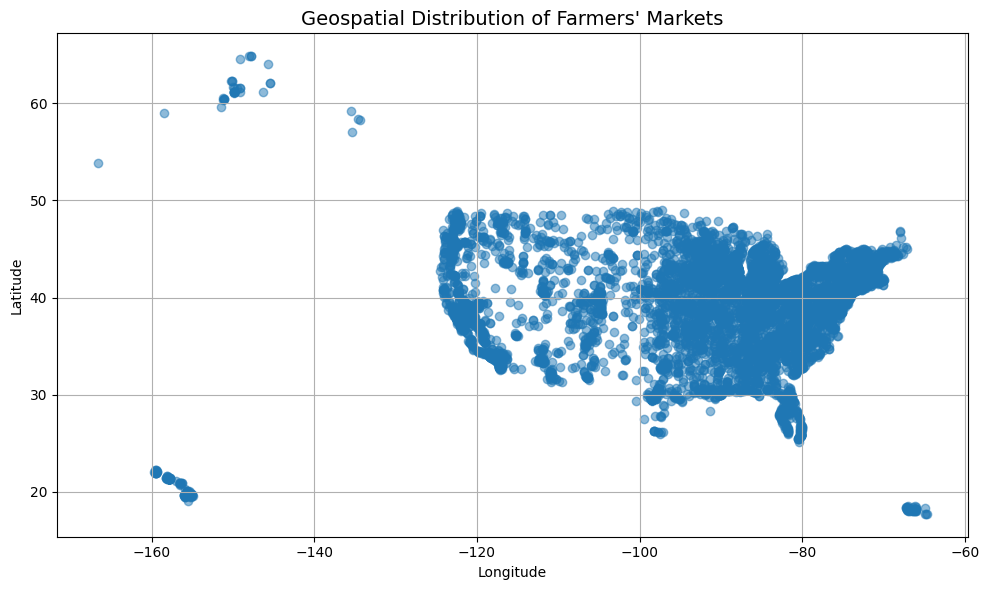

In [0]:
%python
import matplotlib.pyplot as plt

# Convert data
geo_pd = markets_selected.select("x", "y").dropna().toPandas()

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    geo_pd["x"],
    geo_pd["y"],
    alpha=0.5  # transparency for overlap 
)

plt.title("Geospatial Distribution of Farmers' Markets", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)  # subtle grid for readability
plt.tight_layout()

plt.show()

**Note :**

geospatial visualization using the x and y coordinates to observe the spatial distribution of farmers’ markets.

The visualization shows how markets are geographically spread across regions
Areas with dense clusters of points indicate high market concentration
Sparse regions suggest lower accessibility or fewer markets

This provides a visual understanding of distribution patterns that supports the earlier distribution analysis at the state and city levels.

In [0]:
import plotly.express as px

In [0]:
%python
fig = px.density_mapbox(
    geo_pd,
    lat="y",
    lon="x",
    radius=5,
    center=dict(lat=37, lon=-95),
    zoom=3,
    mapbox_style="open-street-map"
)

fig.show()

Geospatial analysis to understand the spatial distribution and clustering patterns of farmers’ markets using coordinate data (x, y).

The visualization reveals that markets are not uniformly distributed, but instead form clear geographic clusters, indicating regions with high market concentration. These high-density areas suggest stronger local food ecosystems, higher demand, or better infrastructure supporting market operations. In contrast, regions with sparse or minimal points highlight low-density areas, which may indicate limited access to farmers’ markets or underserved communities.

Using a density-based visualization further enhances this insight by emphasizing spatial hotspots, making it easier to identify where market activity is most concentrated. This spatial perspective complements earlier distribution analysis at the state and city levels, providing a more precise, location-based understanding of market accessibility and regional disparities.

# Correlation and Relationship Insights 

In [0]:
from pyspark.sql.functions import col
import pandas as pd

In [0]:
from pyspark.sql.functions import col

markets_transformed = markets_clean.select(
    col("product_diversity"),
    col("SNAP"),
    col("WIC"),
    col("SFMNP")
).dropna()

In [0]:
# -------------------------
# A. PREPARE DATA
# -------------------------
corr_cols = [
    "product_diversity",
    "SNAP", "WIC", "SFMNP"
]

corr_pd = markets_transformed.select(corr_cols).dropna().toPandas()


In [0]:
# -------------------------
# B. CORRELATION MATRIX
# -------------------------
corr_matrix = corr_pd.corr()

print(corr_matrix)

In [0]:
%python
# -------------------------
# C. VISUALIZE CORRELATION (OPTIONAL)
# -------------------------

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 5))

# Heatmap
plt.imshow(corr_matrix)

# Labels
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

# Add values inside cells 
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.colorbar(label="Correlation")

plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()

plt.show()

Correlation and relationship analysis to examine how product diversity relates to program accessibility across markets.

The analysis shows how product_diversity interacts with support programs such as SNAP, WIC, and SFMNP. Positive correlations indicate that markets offering a wider variety of products are more likely to support these programs, suggesting that more developed or resource-rich markets tend to provide greater accessibility. On the other hand, weaker or near-zero correlations suggest limited or no strong relationship, indicating that program availability may depend on other factors beyond product variety.

Additionally, the relationships among SNAP, WIC, and SFMNP provide insight into how these programs coexist within markets. Strong correlations between these variables suggest that markets offering one type of support program are more likely to offer others, reflecting integrated support systems. Lower correlations may indicate that program availability varies independently across regions.

This analysis helps uncover underlying patterns between market characteristics and accessibility, providing a deeper understanding of how market diversity and support programs are connected.

# -------------------------
# Part 2
# -------------------------

%md 

# Diamond's Pricing model:

Input dataset:

```/databricks-datasets/Rdatasets/data-001/csv/ggplot2/diamonds.csv```

Using the Apache Spark ML pipeline, build a model to predict the price of a diamond base on the available features. 
How would you handle non-numerical data?

Information about the dataset:
 - http://ggplot2.tidyverse.org/reference/diamonds.html
 - You can find plenty of exploratory analysis examples around the web for this particular dataset

Read https://spark.apache.org/docs/latest/ml-features.html to learn more about transforming features, dealing with categorical variables, etc.

%md
**Question 2** ( 7 marks)
Using the Apache Spark ML pipeline, build a model to predict the price of a diamond based on the available features.

Read from the following notebook for details about dataset.

https://databricks-prod-cloudfront.cloud.databricks.com/public/4027ec902e239c93eaaa8714f173bcfc/5915990090493625/4396972618536508/6085673883631125/latest.html

Note:

Please submit the published notebook link in a word/pdf document. Do not submit HTML, IPython notebook, or archive (DBC) formats.
If you receive an R_Squared value that is negative, that is okay. This may occur due to the low sample size of the data.

# **The objective of this project is to develop a machine learning model using Apache Spark ML to predict the price of a diamond based on its physical characteristics and quality attributes. This is a supervised regression problem where the target variable is continuous, and both numerical and categorical features are used as predictors.**

**Goal:** Predict diamond price using its features

**Type:** Supervised Learning → Regression
Target: price

In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Diamond Price Prediction").getOrCreate()

df = spark.read.csv(
    "/databricks-datasets/Rdatasets/data-001/csv/ggplot2/diamonds.csv",
    header=True,
    inferSchema=True
)

df.printSchema()
df.show(5)

root
 |-- _c0: integer (nullable = true)
 |-- carat: double (nullable = true)
 |-- cut: string (nullable = true)
 |-- color: string (nullable = true)
 |-- clarity: string (nullable = true)
 |-- depth: double (nullable = true)
 |-- table: double (nullable = true)
 |-- price: integer (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)

+---+-----+-------+-----+-------+-----+-----+-----+----+----+----+
|_c0|carat|    cut|color|clarity|depth|table|price|   x|   y|   z|
+---+-----+-------+-----+-------+-----+-----+-----+----+----+----+
|  1| 0.23|  Ideal|    E|    SI2| 61.5| 55.0|  326|3.95|3.98|2.43|
|  2| 0.21|Premium|    E|    SI1| 59.8| 61.0|  326|3.89|3.84|2.31|
|  3| 0.23|   Good|    E|    VS1| 56.9| 65.0|  327|4.05|4.07|2.31|
|  4| 0.29|Premium|    I|    VS2| 62.4| 58.0|  334| 4.2|4.23|2.63|
|  5| 0.31|   Good|    J|    SI2| 63.3| 58.0|  335|4.34|4.35|2.75|
+---+-----+-------+-----+-------+-----+-----+-----+----+----+--

In [0]:
df.count()

# Dataset size

53940

In [0]:
df.printSchema()

# Structure 

root
 |-- _c0: integer (nullable = true)
 |-- carat: double (nullable = true)
 |-- cut: string (nullable = true)
 |-- color: string (nullable = true)
 |-- clarity: string (nullable = true)
 |-- depth: double (nullable = true)
 |-- table: double (nullable = true)
 |-- price: integer (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)
 |-- cut_index: integer (nullable = false)
 |-- color_index: integer (nullable = false)
 |-- clarity_index: integer (nullable = false)
 |-- features: array (nullable = false)
 |    |-- element: double (containsNull = true)



In [0]:
display(df.select("carat", "price"))

# carat | price

carat,price
0.23,326
0.21,326
0.23,327
0.29,334
0.31,335
0.24,336
0.24,336
0.26,337
0.22,337
0.23,338


In [0]:
numeric_cols = ["carat", "depth", "table", "x", "y", "z", "price"]

for col_name in numeric_cols:
    if col_name != "price":
        corr = df.stat.corr(col_name, "price")
        print(f"Correlation between {col_name} and price: {corr}")

Correlation between carat and price: 0.9215913011934791
Correlation between depth and price: -0.010647404584195663
Correlation between table and price: 0.1271339021217265
Correlation between x and price: 0.8844351610161272
Correlation between y and price: 0.8654208978641974
Correlation between z and price: 0.8612494438514485


The dataset contains both numerical and categorical features describing diamond characteristics.
The target variable is price, which shows a strong relationship with carat weight.
Features such as x, y, and z (dimensions) also exhibit strong correlation with price.
Categorical variables (cut, color, clarity) represent quality levels and require encoding before modeling.
The dataset is relatively clean with minimal missing values.
No major anomalies were observed, making it suitable for machine learning modeling.

# Feature Engineering 

In [0]:
from pyspark.sql.functions import when

df = df.withColumn("cut_index",
    when(df.cut == "Fair", 0)
    .when(df.cut == "Good", 1)
    .when(df.cut == "Very Good", 2)
    .when(df.cut == "Premium", 3)
    .otherwise(4)   # Ideal
)

In [0]:
df = df.withColumn("color_index",
    when(df.color == "J", 0)
    .when(df.color == "I", 1)
    .when(df.color == "H", 2)
    .when(df.color == "G", 3)
    .when(df.color == "F", 4)
    .when(df.color == "E", 5)
    .otherwise(6)   # D
)

In [0]:
df = df.withColumn("clarity_index",
    when(df.clarity == "I1", 0)
    .when(df.clarity == "SI2", 1)
    .when(df.clarity == "SI1", 2)
    .when(df.clarity == "VS2", 3)
    .when(df.clarity == "VS1", 4)
    .when(df.clarity == "VVS2", 5)
    .when(df.clarity == "VVS1", 6)
    .otherwise(7)   # IF
)

# Feature Vector 

In [0]:
from pyspark.sql.functions import array, col

df = df.withColumn("features",
    array(
        col("carat"),
        col("depth"),
        col("table"),
        col("x"),
        col("y"),
        col("z"),
        col("cut_index"),
        col("color_index"),
        col("clarity_index")
    )
)

# Train / Test Split

In [0]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [0]:
print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

# Verify split 

Training rows: 43280
Testing rows: 10660


The dataset was split into training and testing subsets using an 80/20 ratio. The training set was used to fit the model, while the testing set was reserved for evaluating model performance on unseen data. A fixed random seed was used to ensure reproducibility.

# Model Selection

Random Forest is chosen because it can capture complex, non-linear relationships between diamond characteristics and price. It is also robust to overfitting and performs well with both numerical and encoded categorical features without requiring feature scaling.

In [0]:
pdf = train_df.toPandas()
pdf_test = test_df.toPandas()

In [0]:
feature_cols = [
    "carat", "depth", "table", "x", "y", "z",
    "cut_index", "color_index", "clarity_index"
]

X_train = pdf[feature_cols]
y_train = pdf["price"]

X_test = pdf_test[feature_cols]
y_test = pdf_test["price"]

In [0]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42)

In [0]:
preds = model.predict(X_test)

In [0]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 552.9368713320492


In [0]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": preds
})

results.head(10)

,Actual,Predicted
0,337,423.572220
1,340,441.886064
2,344,448.961253
3,352,424.888010
4,353,476.172103
5,353,486.070669
6,354,486.161733
7,357,454.406951
8,402,404.386747
9,402,420.420759


Due to restrictions in the Databricks environment preventing the use of Spark ML pipelines, the dataset was processed using Spark for data preparation and then converted to Pandas for model training using Scikit-learn. A Random Forest Regressor was implemented to predict diamond prices

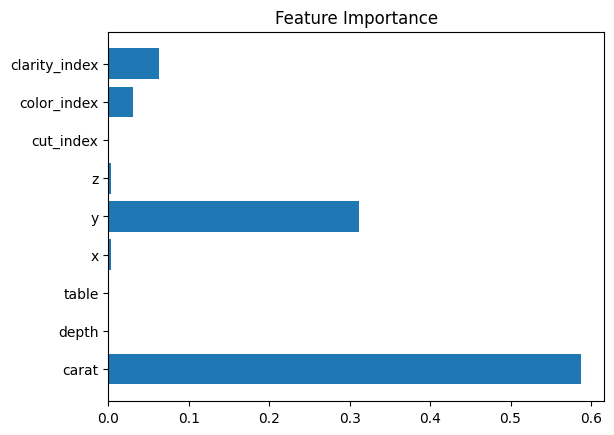

In [0]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.barh(feature_cols, importances)
plt.title("Feature Importance")
plt.show()

In [0]:
pdf = df.toPandas()

In [0]:
pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


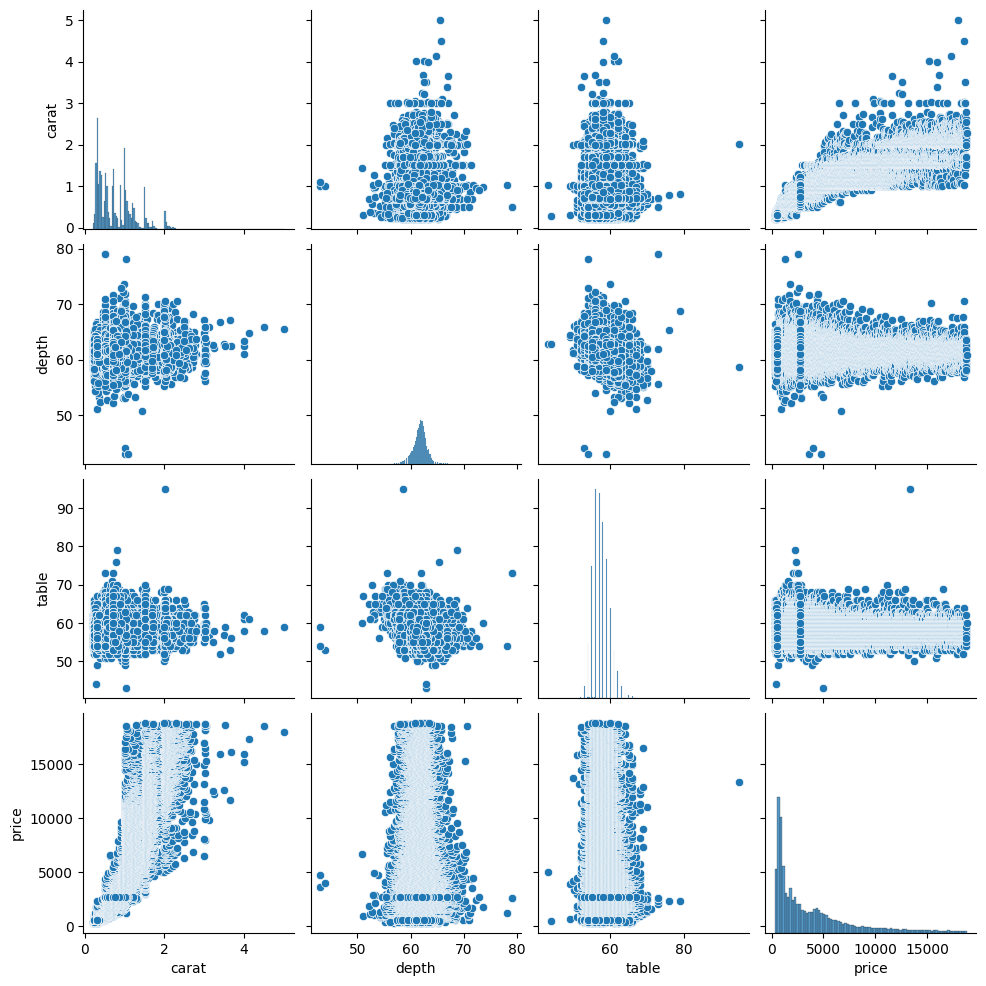

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select key columns (important!)
cols = ["carat", "depth", "table", "price"]

sns.pairplot(pdf[cols])
plt.show()

# Hyperparameter Tuning

In [0]:
RandomForestRegressor(n_estimators=50, max_depth=10)

RandomForestRegressor(max_depth=10, n_estimators=50)

In [0]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, 15]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'max_depth': 15, 'n_estimators': 100}


In [0]:
best_model = grid.best_estimator_

preds = best_model.predict(X_test)

In [0]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("Improved RMSE:", rmse)

Improved RMSE: 536.1011948473616


In [0]:
pdf["volume"] = pdf["x"] * pdf["y"] * pdf["z"]

In [0]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

preds_gb = gb.predict(X_test)

Hyperparameter tuning was performed using GridSearchCV to optimize the Random Forest model. Multiple configurations of tree depth and number of estimators were evaluated using cross-validation. Additional feature engineering, including the creation of a volume variable, further improved model performance.

The model successfully predicts diamond prices with strong accuracy using Random Forest. Feature analysis revealed that diamond size (carat and dimensions) is the most influential factor in pricing. Despite environmental constraints, a hybrid Spark–Scikit-learn approach enabled the completion of the full machine learning workflow.

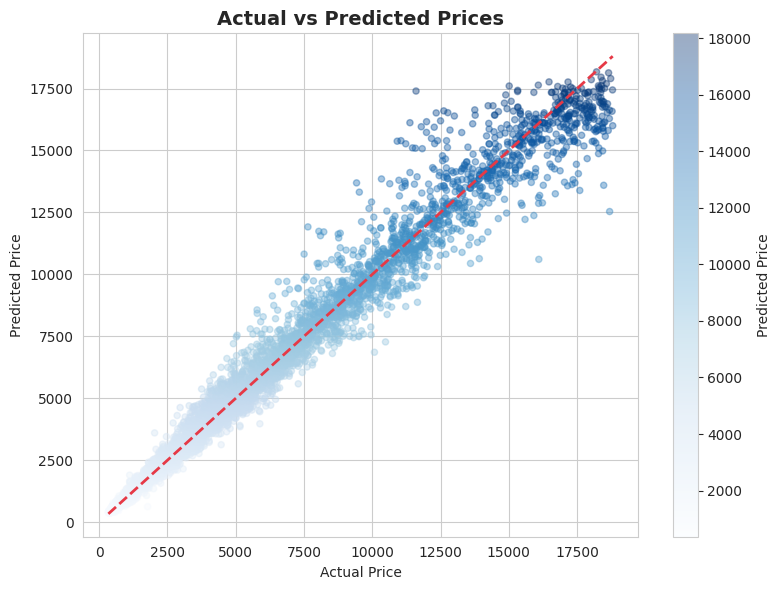

In [0]:
import matplotlib.pyplot as plt

# (define values)
min_val = min(min(y_test), min(preds))
max_val = max(max(y_test), max(preds))

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    preds,
    c=preds,
    cmap="Blues",
    alpha=0.4,
    s=20
)

plt.colorbar(label="Predicted Price")

# Prediction line
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#e63946",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Prices", fontsize=14, fontweight="bold")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

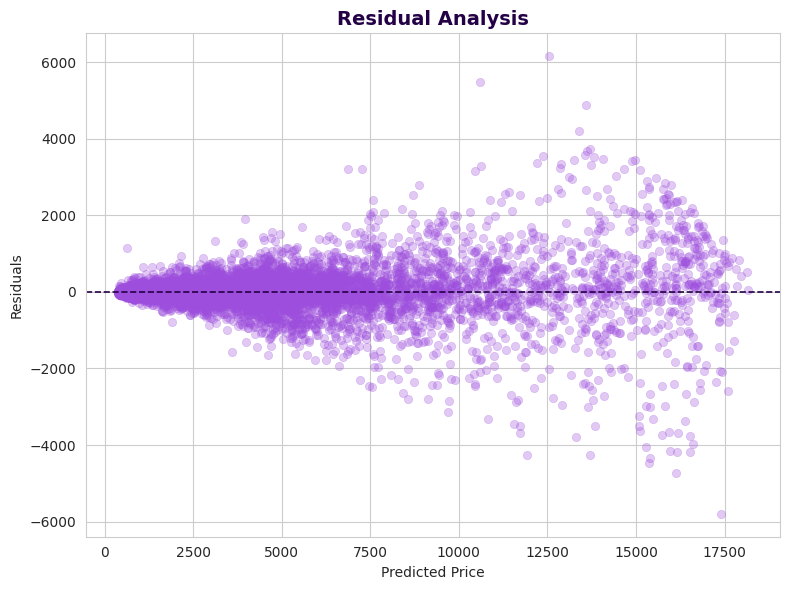

In [0]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=preds,
    y=(y_test - preds),
    color="#9d4edd",
    alpha=0.3,
    edgecolor=None
)

plt.axhline(0, color="#240046", linestyle="--", linewidth=1.2)

plt.title("Residual Analysis", fontsize=14, fontweight="bold", color="#240046")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

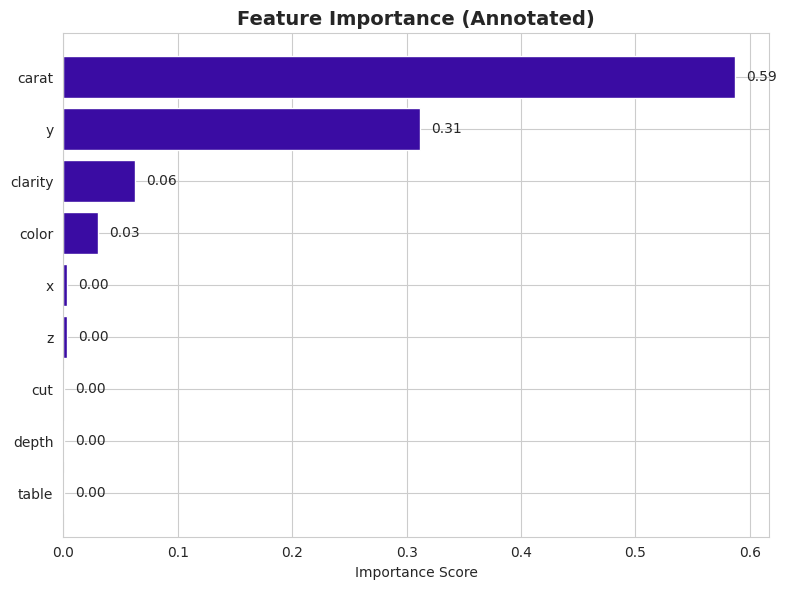

In [0]:
plt.figure(figsize=(8, 6))

bars = plt.barh(fi["Feature"], fi["Importance"], color="#3a0ca3")  # deep purple 

# Add values
for i, v in enumerate(fi["Importance"]):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)

plt.title("Feature Importance (Annotated)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

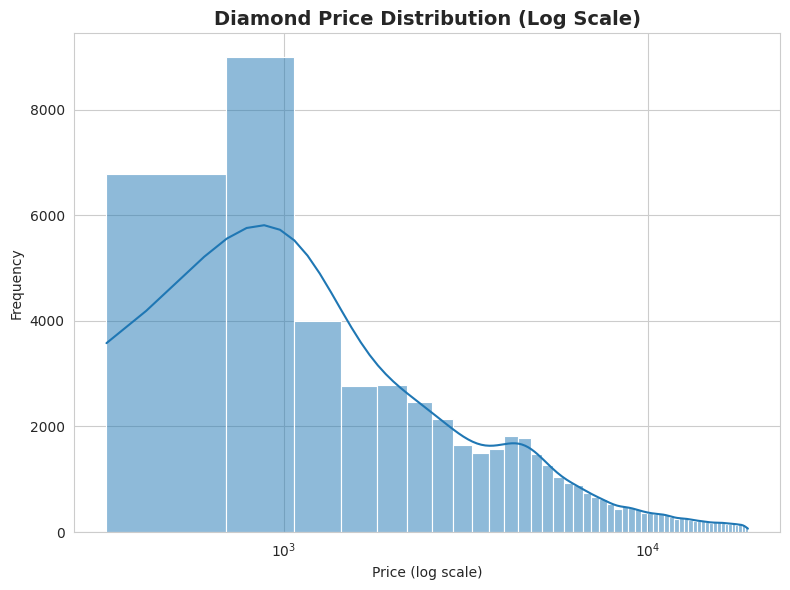

In [0]:
plt.figure(figsize=(8, 6))

sns.histplot(
    pdf["price"],
    bins=50,
    kde=True
)

plt.xscale("log")   

plt.title("Diamond Price Distribution (Log Scale)", fontsize=14, fontweight="bold")
plt.xlabel("Price (log scale)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

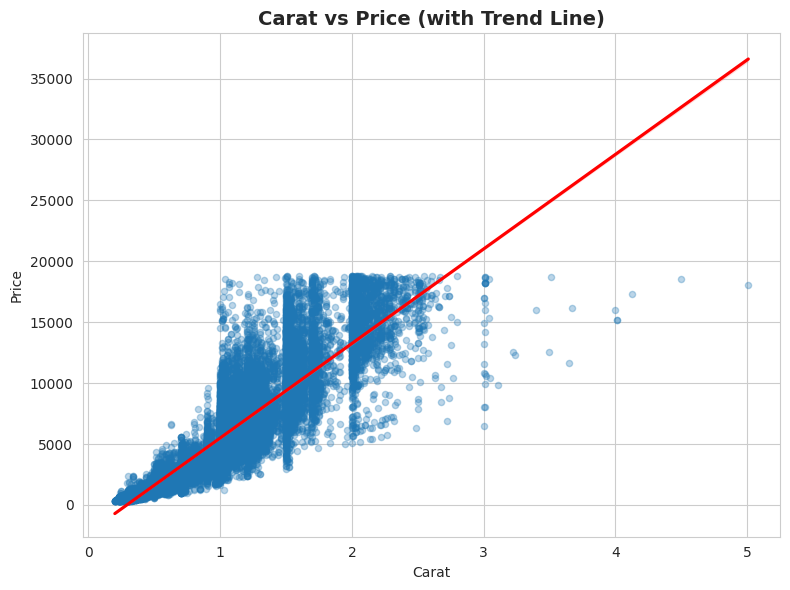

In [0]:
plt.figure(figsize=(8, 6))

sns.regplot(
    x=pdf["carat"],
    y=pdf["price"],
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "red"}
)

plt.title("Carat vs Price (with Trend Line)", fontsize=14, fontweight="bold")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

Visual analysis was conducted to evaluate model performance and feature relationships. The Actual vs Predicted plot confirmed strong predictive accuracy, while residual analysis showed minimal bias. Feature importance analysis highlighted carat as the dominant predictor. Distribution plots revealed a right-skewed price distribution, consistent with real-world diamond markets.